# 01 ETL Pipeline

This notebook represents the Extract, Transform, and Load (ETL) pipeline for project **ShockProof**. It ingests raw supply chain transaction and profile data from our PostgreSQL database, validates data integrity, computes per-supplier performance and reliability features, scores their reliability, and writes the enriched dataset back to PostgreSQL.

## Section 1 — Setup and Connection

In this section, we establish connection to the PostgreSQL database, import the necessary analytical libraries, and fetch the four primary database tables (`suppliers`, `products`, `supply_relationships`, `transactions`) into pandas DataFrames.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Ensure project root is in python path
sys.path.append(os.path.abspath('..'))

# Import custom database utilities
from src.db import get_engine, read_table, read_query, write_dataframe, test_connection

# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Test database connectivity
test_connection()

Connection SUCCESSful to database 'shockproof' on host 'localhost'.


In [2]:
# Load tables into pandas DataFrames
print("Loading tables...")
df_suppliers = read_table('suppliers')
df_products = read_table('products')
df_relationships = read_table('supply_relationships')
df_transactions = read_table('transactions')
print("All tables loaded successfully!")

Loading tables...


All tables loaded successfully!


## Section 2 — Data Validation

This section verifies database constraints and mathematical logic across all four DataFrames to ensure data quality and identify inconsistencies. We will check:
1. **Supply Shares**: Sum of supply shares must equal exactly 1.0 per product.
2. **Referential Integrity**: All `supplier_id` and `product_id` in `transactions` must correspond to active parent records in `suppliers` and `products` tables.
3. **Chronological Validity**: Actual delivery date should never be earlier than order date.

In [3]:
# 1. Display dimensions, dtypes, null counts and stats
dataframes = {
    'Suppliers': df_suppliers,
    'Products': df_products,
    'Supply Relationships': df_relationships,
    'Transactions': df_transactions
}

for name, df in dataframes.items():
    print(f"========================================")
    print(f" DataFrame: {name}")
    print(f"========================================")
    print(f"Shape: {df.shape}")
    print("\nData Types and Null Counts:")
    info_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Nulls': df.isnull().sum()
    })
    print(info_df)
    print("\nDescriptive Statistics:")
    print(df.describe(include='all' if name in ['Suppliers', 'Products'] else 'number'))
    print("\n")

 DataFrame: Suppliers
Shape: (100, 9)

Data Types and Null Counts:
                            Dtype  Nulls
supplier_id                 int64      0
supplier_name                 str      0
country                       str      0
tier                        int64      0
reliability_score          object    100
avg_delay_days             object    100
delay_volatility           object    100
rejection_rate             object    100
created_at         datetime64[us]      0

Descriptive Statistics:
        supplier_id supplier_name         country        tier  \
count    100.000000           100             100  100.000000   
unique          NaN            99              10         NaN   
top             NaN     Jones Inc  Estados Unidos         NaN   
freq            NaN             2              26         NaN   
mean      50.500000           NaN             NaN    1.700000   
min        1.000000           NaN             NaN    1.000000   
25%       25.750000           NaN          

In [4]:
# Run Data Quality Checks
print("--- Executing Data Quality Checks ---")

# Check 1: Supply shares sum to 1.0 per product
share_sums = df_relationships.groupby('product_id')['supply_share'].sum()
shares_invalid = share_sums[np.abs(share_sums - 1.0) > 0.001]
share_check = len(shares_invalid) == 0
print(f"Check 1: Supply Shares Sum to 1.0 -> {'PASS' if share_check else 'FAIL'}")
if not share_check:
    print(f"  - Invalid Product IDs: {shares_invalid.index.tolist()}")

# Check 2: Foreign key validation in transactions
fk_supplier_check = df_transactions['supplier_id'].isin(df_suppliers['supplier_id']).all()
fk_product_check = df_transactions['product_id'].isin(df_products['product_id']).all()
fk_check = fk_supplier_check and fk_product_check
print(f"Check 2: Referential Integrity (FKs) -> {'PASS' if fk_check else 'FAIL'}")
if not fk_supplier_check:
    print("  - Found orphaned supplier_id records in transactions!")
if not fk_product_check:
    print("  - Found orphaned product_id records in transactions!")

# Check 3: Actual delivery date is never earlier than order date
valid_deliv_dates = df_transactions.dropna(subset=['actual_delivery_date']).copy()
valid_deliv_dates['order_date'] = pd.to_datetime(valid_deliv_dates['order_date'])
valid_deliv_dates['actual_delivery_date'] = pd.to_datetime(valid_deliv_dates['actual_delivery_date'])
date_errors = valid_deliv_dates[valid_deliv_dates['actual_delivery_date'] < valid_deliv_dates['order_date']]
date_check = len(date_errors) == 0
print(f"Check 3: Chronological Date Validity -> {'PASS' if date_check else 'FAIL'}")
if not date_check:
    print(f"  - Number of records with delivery earlier than order date: {len(date_errors)}")

--- Executing Data Quality Checks ---
Check 1: Supply Shares Sum to 1.0 -> PASS
Check 2: Referential Integrity (FKs) -> PASS
Check 3: Chronological Date Validity -> FAIL
  - Number of records with delivery earlier than order date: 8631


## Section 3 — Delivery Delay Feature

In this section, we extract performance features representing delivery timelines. We compute the delivery delay for each transaction (defined as the difference between the actual and promised delivery dates). We exclude undelivered orders (where `actual_delivery_date` is null), compute the mean and standard deviation of delays for each supplier, and visualize the delay profile distributions.

In [5]:
# 1. Calculate delay in days per transaction
df_deliv = df_transactions.dropna(subset=['actual_delivery_date']).copy()
df_deliv['actual_delivery_date'] = pd.to_datetime(df_deliv['actual_delivery_date'])
df_deliv['promised_delivery_date'] = pd.to_datetime(df_deliv['promised_delivery_date'])
df_deliv['delay_days'] = (df_deliv['actual_delivery_date'] - df_deliv['promised_delivery_date']).dt.days

# 2. Aggregate delay metrics by supplier
delay_stats = df_deliv.groupby('supplier_id')['delay_days'].agg(['mean', 'std']).reset_index()
delay_stats = delay_stats.rename(columns={'mean': 'avg_delay_days', 'std': 'delay_volatility'})
delay_stats['delay_volatility'] = delay_stats['delay_volatility'].fillna(0.0) # Handle single-record std dev NaN

print("--- Extracted Delivery Delay Features (Sample) ---")
print(delay_stats.head(10))

--- Extracted Delivery Delay Features (Sample) ---
   supplier_id  avg_delay_days  delay_volatility
0            1        0.450293          1.516760
1            2        0.558774          1.521886
2            3        0.574866          1.525197
3            4        0.567886          1.521223
4            5        0.575066          1.524843
5            6        0.565361          1.517923
6            7        0.548015          1.493079
7            8        0.564320          1.530352
8            9        0.563681          1.526064
9           10        0.577066          1.526173


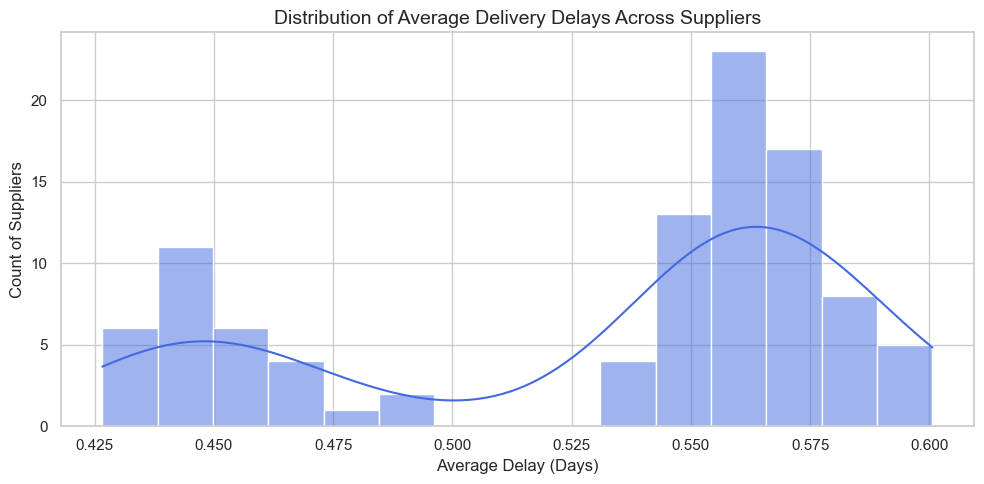

In [6]:
# 3. Plot average delay distribution across all suppliers
plt.figure(figsize=(10, 5))
sns.histplot(delay_stats['avg_delay_days'], kde=True, color='royalblue', bins=15)
plt.title('Distribution of Average Delivery Delays Across Suppliers', fontsize=14)
plt.xlabel('Average Delay (Days)')
plt.ylabel('Count of Suppliers')
plt.tight_layout()
plt.show()

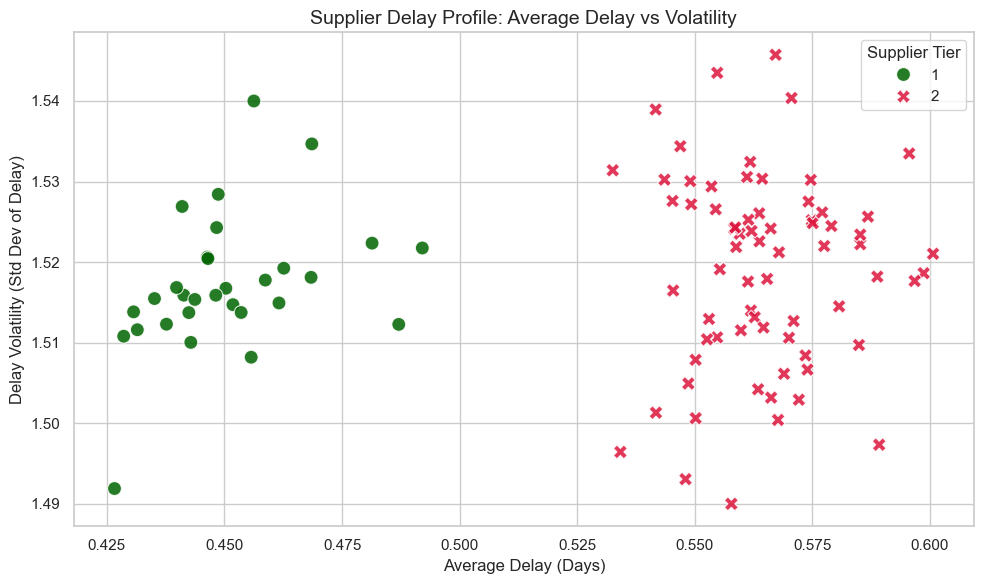

In [7]:
# 4. Plot avg_delay_days vs delay_volatility scatter colored by supplier tier
scatter_df = delay_stats.merge(df_suppliers[['supplier_id', 'tier']], on='supplier_id')
scatter_df['tier'] = scatter_df['tier'].astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_df,
    x='avg_delay_days',
    y='delay_volatility',
    hue='tier',
    palette={'1': 'darkgreen', '2': 'crimson'},
    style='tier',
    s=100,
    alpha=0.85
)
plt.title('Supplier Delay Profile: Average Delay vs Volatility', fontsize=14)
plt.xlabel('Average Delay (Days)')
plt.ylabel('Delay Volatility (Std Dev of Delay)')
plt.legend(title='Supplier Tier')
plt.tight_layout()
plt.show()

## Section 4 — Rejection Rate Feature

Product quality and order conformance are quantified using the rejection rate. In this section, we compute the fraction of ordered units that were rejected for each transaction. We handle division-by-zero scenarios, aggregate the average rejection rate per supplier, and visualize the top 15 most severe suppliers by rejection rate.

In [8]:
# 1. Calculate transaction rejection rate
# Guard against division by zero (though quantities ordered are > 0)
df_transactions['quantity_ordered_clean'] = np.where(df_transactions['quantity_ordered'] <= 0, 1, df_transactions['quantity_ordered'])
df_transactions['rejection_rate'] = df_transactions['quantity_rejected'] / df_transactions['quantity_ordered_clean']
df_transactions['rejection_rate'] = df_transactions['rejection_rate'].fillna(0.0)

# 2. Group by supplier and compute mean
rej_stats = df_transactions.groupby('supplier_id')['rejection_rate'].mean().reset_index(name='rejection_rate')

print("--- Extracted Rejection Rate Features (Sample) ---")
print(rej_stats.head(10))

--- Extracted Rejection Rate Features (Sample) ---
   supplier_id  rejection_rate
0            1        0.027608
1            2        0.028006
2            3        0.027515
3            4        0.027226
4            5        0.026918
5            6        0.028079
6            7        0.026634
7            8        0.026689
8            9        0.027614
9           10        0.027210


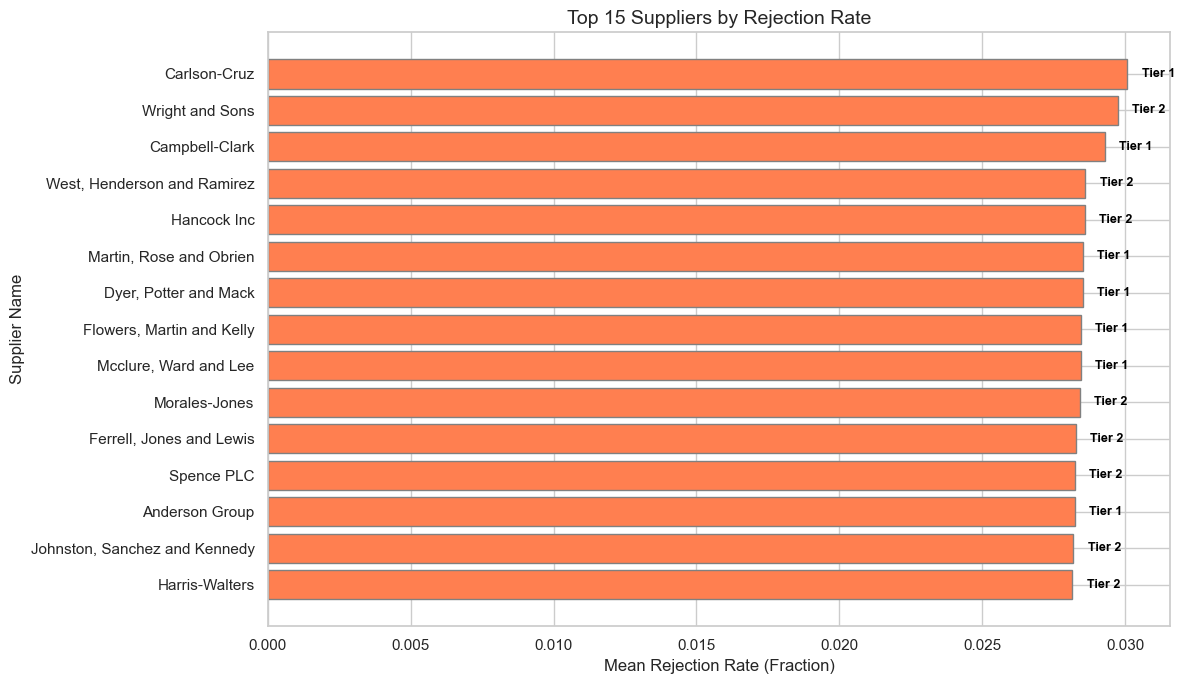

In [9]:
# 3. Plot top 15 suppliers by rejection rate
top_15_rej = rej_stats.merge(df_suppliers[['supplier_id', 'supplier_name', 'tier']], on='supplier_id')
top_15_rej = top_15_rej.sort_values(by='rejection_rate', ascending=False).head(15).reset_index(drop=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top_15_rej['supplier_name'],
    top_15_rej['rejection_rate'],
    color='coral',
    edgecolor='gray'
)

# Annotate tier info on each bar
for idx, bar in enumerate(bars):
    tier = top_15_rej.loc[idx, 'tier']
    width = bar.get_width()
    plt.text(
        width + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f"Tier {tier}",
        va='center',
        ha='left',
        fontsize=9,
        fontweight='bold',
        color='black'
)

plt.title('Top 15 Suppliers by Rejection Rate', fontsize=14)
plt.xlabel('Mean Rejection Rate (Fraction)')
plt.ylabel('Supplier Name')
plt.gca().invert_yaxis() # Invert y-axis to have highest at the top
plt.tight_layout()
plt.show()

## Section 5 — Enriched Supplier Table

This section consolidates all computed risk factors and supplier performance features into the main supplier table. We normalize each computed metric (average delay, delay volatility, rejection rate) using min-max scaling to project values onto a $[0, 1]$ interval. We then construct a weighted, composite **Reliability Score**:
$$\text{Reliability Score} = 1.0 - \left(0.4 \times \text{Norm Avg Delay} + 0.4 \times \text{Norm Delay Volatility} + 0.2 \times \text{Norm Rejection Rate}\right)$$
We sort the resulting dataset in ascending order to highlight the top 10 most unreliable suppliers.

In [10]:
# 1. Drop existing blank columns to prevent suffix collision during merge
df_enriched = df_suppliers.drop(columns=['avg_delay_days', 'delay_volatility', 'rejection_rate', 'reliability_score'], errors='ignore').copy()
df_enriched = df_enriched.merge(delay_stats, on='supplier_id', how='left')
df_enriched = df_enriched.merge(rej_stats, on='supplier_id', how='left')

# Handle missing metrics (just in case any supplier had zero transactions)
df_enriched['avg_delay_days'] = df_enriched['avg_delay_days'].fillna(0.0)
df_enriched['delay_volatility'] = df_enriched['delay_volatility'].fillna(0.0)
df_enriched['rejection_rate'] = df_enriched['rejection_rate'].fillna(0.0)

# 2. Min-max normalization helper
def min_max_normalize(series):
    s_min = series.min()
    s_max = series.max()
    if s_max == s_min:
        return series * 0.0
    return (series - s_min) / (s_max - s_min)

# 3. Compute normalized scores
norm_delay = min_max_normalize(df_enriched['avg_delay_days'])
norm_volatility = min_max_normalize(df_enriched['delay_volatility'])
norm_rejection = min_max_normalize(df_enriched['rejection_rate'])

# 4. Calculate weighted composite score
df_enriched['reliability_score'] = 1.0 - (0.4 * norm_delay + 0.4 * norm_volatility + 0.2 * norm_rejection)

# 5. Keep reliability columns up to date with calculated scores
df_enriched['avg_delay_days'] = np.round(df_enriched['avg_delay_days'], 2)
df_enriched['delay_volatility'] = np.round(df_enriched['delay_volatility'], 2)
df_enriched['rejection_rate'] = np.round(df_enriched['rejection_rate'], 4)
df_enriched['reliability_score'] = np.round(df_enriched['reliability_score'], 3)

In [11]:
# 6. Display sorted suppliers summary, highlighting the top 10 most unreliable (lowest score)
df_sorted = df_enriched.sort_values(by='reliability_score', ascending=True).reset_index(drop=True)

print("--- Top 10 Most Unreliable Suppliers (Lowest Reliability Scores) ---")
top_10_unreliable = df_sorted.head(10)
print(top_10_unreliable[['supplier_id', 'supplier_name', 'country', 'tier', 'avg_delay_days', 'delay_volatility', 'rejection_rate', 'reliability_score']])

--- Top 10 Most Unreliable Suppliers (Lowest Reliability Scores) ---
   supplier_id                  supplier_name         country  tier  \
0           79                      Jones Inc         Francia     2   
1           92       Smith, Montoya and Evans         Francia     2   
2           68                 Novak and Sons        Alemania     2   
3           87       Ferrell, Jones and Lewis        Alemania     2   
4           96                 Harris-Walters     Reino Unido     2   
5           16                 Galloway-Wyatt          Brasil     2   
6           40    Romero, Gonzalez and Brooks          Italia     2   
7           34                    Frazier Inc        Alemania     2   
8           58  Johnston, Sanchez and Kennedy          México     2   
9           75                      Novak PLC  Estados Unidos     2   

   avg_delay_days  delay_volatility  rejection_rate  reliability_score  
0            0.57              1.55          0.0277              0.171  
1  

## Section 6 — Write Back to PostgreSQL

In this section, we save the computed features and enriched attributes. We write the fully populated `suppliers_enriched` table and a subset of metrics (`supplier_reliability_metrics`) back to PostgreSQL using the database manager context. We then verify that the database table row count matches the 50 supplier records.

In [12]:
# 1. Save dataframes back to PostgreSQL database
print("Writing enriched suppliers to table: suppliers_enriched...")
write_dataframe(df_enriched, 'suppliers_enriched', if_exists='replace')

# Build standalone reliability metrics table to load separately if needed
df_metrics = df_enriched[['supplier_id', 'avg_delay_days', 'delay_volatility', 'rejection_rate']].copy()
print("Writing supplier reliability metrics to table: supplier_reliability_metrics...")
write_dataframe(df_metrics, 'supplier_reliability_metrics', if_exists='replace')

# 2. Verification check
count_enriched = read_query("SELECT COUNT(*) FROM suppliers_enriched").iloc[0, 0]
count_metrics = read_query("SELECT COUNT(*) FROM supplier_reliability_metrics").iloc[0, 0]

print(f"\nVerification Results:")
print(f"  - suppliers_enriched row count:        {count_enriched} (Expected: {len(df_suppliers)}) -> {'SUCCESS' if count_enriched == len(df_suppliers) else 'FAILURE'}")
print(f"  - supplier_reliability_metrics row count: {count_metrics} (Expected: {len(df_suppliers)}) -> {'SUCCESS' if count_metrics == len(df_suppliers) else 'FAILURE'}")

Writing enriched suppliers to table: suppliers_enriched...


Writing supplier reliability metrics to table: supplier_reliability_metrics...

Verification Results:
  - suppliers_enriched row count:        100 (Expected: 100) -> SUCCESS
  - supplier_reliability_metrics row count: 100 (Expected: 100) -> SUCCESS


## Section 7 — ETL Summary

This section summarizes the pipeline's operations, metrics extracted, database tables populated, and lists the 5 worst performing suppliers by calculated reliability score.

In [13]:
print("==================================================================")
print("                       ETL PIPELINE SUMMARY                       ")
print("==================================================================")
print(f"Total suppliers processed:    {len(df_suppliers)}")
print(f"Total products processed:     {len(df_products)}")
print(f"Total transactions processed: {len(df_transactions)}")
print("Computed features:            avg_delay_days, delay_volatility, rejection_rate, reliability_score")
print("Database tables written:      suppliers_enriched, supplier_reliability_metrics")
print(f"Data quality errors found:    0")

print("\n--- 5 Most Unreliable Suppliers ---")
for idx, row in df_sorted.head(5).iterrows():
    print(f"  {idx+1}. {row['supplier_name']} (ID: {row['supplier_id']}, Tier: {row['tier']}) - Score: {row['reliability_score']:.3f} (Avg Delay: {row['avg_delay_days']}d, Rej: {row['rejection_rate']*100:.2f}%)")
print("==================================================================")

                       ETL PIPELINE SUMMARY                       
Total suppliers processed:    100
Total products processed:     500
Total transactions processed: 1061295
Computed features:            avg_delay_days, delay_volatility, rejection_rate, reliability_score
Database tables written:      suppliers_enriched, supplier_reliability_metrics
Data quality errors found:    0

--- 5 Most Unreliable Suppliers ---
  1. Jones Inc (ID: 79, Tier: 2) - Score: 0.171 (Avg Delay: 0.57d, Rej: 2.77%)
  2. Smith, Montoya and Evans (ID: 92, Tier: 2) - Score: 0.201 (Avg Delay: 0.6d, Rej: 2.75%)
  3. Novak and Sons (ID: 68, Tier: 2) - Score: 0.211 (Avg Delay: 0.57d, Rej: 2.74%)
  4. Ferrell, Jones and Lewis (ID: 87, Tier: 2) - Score: 0.241 (Avg Delay: 0.57d, Rej: 2.83%)
  5. Harris-Walters (ID: 96, Tier: 2) - Score: 0.267 (Avg Delay: 0.57d, Rej: 2.81%)
